<p style="text-align: center; font-size: 30px;">
    <strong>
          Análisis de las opiniones de los usuarios en Amazon.es
    </strong>
</p>


<b style="text-align: left; font-size: 18px;">
    Este proyecto tiene como objetivo analizar las opiniones sobre diferentes tipos de cafeteras vendidas en Amazon.es
</b>

----

<b style="font-size: 20px;">Plan del proyecto</b>

-  <p style="font-size: 18px;">Depurar los datos recopilados de los textos (reseñas) irrelevantes</p>
-  <p style="font-size: 18px;">Clasificar las opiniones dentro de cada categoría de los productos (análisis de sentimiento)</p>
-  <p style="font-size: 18px;">Descubrir los temas más mencionados por los consumidores en sus reseñas (topic modeling) </p>
---

<b style="font-size: 20px;">Herramientas necesarias</b>

<blockquote style="background-color: #f0f0f0; padding: 10px; border-left: 10px solid #3498db; font-size: 18px;">
    Biblioteca Langdetect para clasificar los textos por idioma
</blockquote>

In [ ]:
!pip install langdetect

<blockquote style="background-color: #f0f0f0; padding: 10px; border-left: 10px solid #3498db; font-size: 18px;">
    Biblioteca Pandas para el almacenamiento y la manipulación de datos
</blockquote>

In [ ]:
!pip install pandas

<blockquote style="background-color: #f0f0f0; padding: 10px; border-left: 10px solid #3498db; font-size: 18px;">
    Biblioteca TQDM para vizualizar la barra de progreso 
</blockquote>

In [ ]:
!pip install tqdm

<blockquote style="background-color: #f0f0f0; padding: 10px; border-left: 10px solid #3498db; font-size: 18px;">
    Biblioteca Spacy para el procesamiento del lenguaje natural
</blockquote>

In [ ]:
!pip install spacy

<blockquote style="background-color: #f0f0f0; padding: 10px; border-left: 10px solid #3498db; font-size: 18px;">
    Biblioteca TextBlob para el procesamiento del lenguaje natural 
</blockquote>

In [ ]:
!pip install textblob

<blockquote style="background-color: #f0f0f0; padding: 10px; border-left: 10px solid #3498db; font-size: 18px;">
    Biblioteca PySentimiento para el análisis de sentimiento
</blockquote>

In [ ]:
!pip install pysentimiento

<blockquote style="background-color: #f0f0f0; padding: 10px; border-left: 10px solid #3498db; font-size: 18px;">
    Biblioteca Matplotlib para gráficos
</blockquote>

In [ ]:
!pip install matplotlib

<blockquote style="background-color: #f0f0f0; padding: 10px; border-left: 10px solid #3498db; font-size: 18px;">
    Transformers for pipeline (interacción fácil con modelos basados en la arquitectura Transformer)
</blockquote>

In [ ]:
!pip install transformers

<blockquote style="background-color: #f0f0f0; padding: 10px; border-left: 10px solid #3498db; font-size: 18px;">
    Wordcloud y pyLDAvis para visualización de los datos 
</blockquote>

In [ ]:
!pip install wordcloud

In [ ]:
!pip install pyLDAvis

<blockquote style="background-color: #f0f0f0; padding: 10px; border-left: 10px solid #3498db; font-size: 18px;">
    Sklearn para la creaión del modelo LSA 
</blockquote>

In [ ]:
!pip install scikit-learn

<blockquote style="background-color: #f0f0f0; padding: 10px; border-left: 10px solid #3498db; font-size: 18px;">
    Ipywidgets para una interfaz de usuario interactiva (UI)
</blockquote>

In [ ]:
!pip install ipywidgets

---
<b style="font-size: 20px;">Importación de las bibliotecas necesarias</b>

In [2]:
from langdetect import detect
from textblob import TextBlob
from pysentimiento import create_analyzer
from transformers import pipeline
import spacy

import pandas as pd
import numpy as np
from tqdm import tqdm
import os

from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator

import ipywidgets as widgets

import time
import datetime

# LDA
import gensim
from gensim import corpora
from gensim.models.callbacks import CallbackAny2Vec
from gensim.models import CoherenceModel
from collections import Counter
from gensim.corpora.dictionary import Dictionary

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from wordcloud import WordCloud
import re
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# LSA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer

import pickle
from io import BytesIO
import base64
from collections import defaultdict
import json

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/innafilatova/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/innafilatova/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/innafilatova/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

---
<b style="font-size: 20px;">
    Depuración de los datos de las reseñas no españolas
</b>

In [12]:
from tqdm import tqdm

def is_spanish(text):
    try:
        return detect(text) == 'es'
    except: #en caso de error o idioma no detectado
        return False

def filter_reseñas_esp(filename):
    df = pd.read_csv(filename)
    count_original = df.shape[0]
    
    filtered_df = df[df["body"].apply(is_spanish)]
    count_final = filtered_df.shape[0]

    if count_final > 0:
        filtered_df.to_csv(filename, index=False, encoding="utf-8")
    else:
        df.head(0).to_csv(filename, index=False, encoding="utf-8")

    diff = count_original - count_final 
    return (filtered_df, diff)

if __name__ == "__main__":
    base_df = pd.read_csv('new_database/base.csv')

    dataframes = []

    for ID in base_df['ID']:
        id_df = pd.read_csv(f'new_database/{ID}.csv')
        category = base_df.loc[base_df['ID'] == ID, 'category'].values

        reviews_df = pd.DataFrame()

        for local_id in tqdm(id_df['ID'], desc=f"Processing local_IDs for {ID}.csv"):
            review_filename = f'new_database/reviews/{local_id}.csv'
        
            (filtered_df, count) = filter_reseñas_esp(review_filename)

            reviews_df = pd.concat([reviews_df, filtered_df], ignore_index=True)
        
        print('-'*50 + f'\nReviews left in the {category[0]} category: {reviews_df.shape[0]}\n')
        dataframes.append(reviews_df)

    for i in range(len(dataframes)):
        dataframes[i].to_csv(f'new_database/analysis/category_{i}.csv', index = False, encoding = "utf-8")

Processing local_IDs for 0.csv: 100%|█████████| 279/279 [04:04<00:00,  1.14it/s]


--------------------------------------------------
Reviews left in the Cafeteras de goteo category: 20495



Processing local_IDs for 1.csv: 100%|███████████| 98/98 [02:16<00:00,  1.40s/it]


--------------------------------------------------
Reviews left in the Cafeteras automaticas category: 16073



Processing local_IDs for 2.csv: 100%|█████████| 148/148 [02:37<00:00,  1.07s/it]


--------------------------------------------------
Reviews left in the Cafeteras individuales category: 19085



In [14]:
base_df = pd.read_csv('new_database/base.csv')
all_reviews = pd.DataFrame()

for ID in base_df['ID']:
    id_df = pd.read_csv(f'new_database/{ID}.csv')
    category = base_df.loc[base_df['ID'] == ID, 'category'].values
    
    reviews_df = pd.DataFrame()
    
    for local_id in id_df['ID']:
        review_file = f'new_database/reviews/{local_id}.csv'
        
        if os.path.exists(review_file):
            try:
                review_df = pd.read_csv(review_file)
            except:
                print(f'Error parsing {review_file}')
                continue
            reviews_df = pd.concat([reviews_df, review_df], ignore_index=True)
    
    print(f'Located {len(reviews_df)} reviews in {category[0]} category.')

    all_reviews = pd.concat([all_reviews, reviews_df], ignore_index=True)

print('-'*50 + f'\nTotal number of reviews in the new_database: {len(all_reviews)}\n' + '-'*50)

all_reviews.head()

Located 20495 reviews in Cafeteras de goteo category.
Located 16073 reviews in Cafeteras automaticas category.
Located 19085 reviews in Cafeteras individuales category.
--------------------------------------------------
Total number of reviews in the new_database: 55653
--------------------------------------------------


,title,rating,body,author,date
0,Regalo,"5,0 de 5 estrellas",Me gustó mucho,Cliente Amazon,Revisado en España el 6 de abril de 2024
1,No ha durado ni la garantía + pésimo servicio ...,"1,0 de 5 estrellas","Ni los 24 meses de garantía ha durado, y al en...",MaX,Revisado en España el 3 de abril de 2024
2,Está bien,"3,0 de 5 estrellas",Después de más de dos meses usándola hace muy ...,Lorena,Revisado en España el 14 de marzo de 2024
3,Perfecta!,"5,0 de 5 estrellas",Me encanta! Soy adicta al café y me gusta toma...,Perfecta!,Revisado en España el 22 de febrero de 2024
4,EXCELENTE,"5,0 de 5 estrellas",como única pega que limpiar el palito del vapo...,Sil at,Revisado en España el 20 de febrero de 2024


----
<p style="text-align: center; font-size: 25px; margin-top: 20px;">
    <strong>
          Análisis de sentimiento
    </strong>
</p>

----


<b style="font-size: 20px;">
    Visualización de tablas y gráficos
</b>
<p style="font-size: 18px;">Definición de las funciones para una fácil demostración de los resultados.</p>

In [117]:
def show_pie_chart(polarities):
    base = pd.read_csv("new_database/base.csv") # nombrar categorías
    categories = []
    
    for i in base["category"]:
        categories.append(i)

    labels = ['Positive', 'Neutral', 'Negative']
    fig, axis = plt.subplots(1, 3, figsize=(18, 6)) # crear una forma y un eje

    for i, (ax, data) in enumerate(zip(axis, polarities)):
        ax.pie(data, labels=labels, autopct='%1.1f%%', colors=['#66b3ff','#ffcc99','#ff6666'])
        ax.set_title(categories[i])

    plt.tight_layout() #mostrar diagramas 
    plt.show()

def load_polarities_from_csv(type):
    polarities = []
    for i in range(3):
        
        df = pd.read_csv(f'new_database/analysis/analyzed_category_{i}.csv')

        if type not in df.columns: # si la columna no existe
            raise ValueError(f"Column '{type}' does not exist in the DataFrame.")

        counts = df[type].value_counts() # contar el número de valores diferentes en las columnas
    
        result = ( # cortege 
            counts.get('POS', 0),
            counts.get('NEU', 0),
            counts.get('NEG', 0)
        )

        polarities.append(result)
    
    return polarities

def show_comparison():
    base = pd.read_csv("new_database/base.csv") # nombrar categorías
    categories = []
    
    for i in base["category"]:
        categories.append(i)

    for i in range(3):
        df = pd.read_csv(f'new_database/analysis/analyzed_category_{i}.csv')
    
        # Localizar las cinco primeras palabras no coincidentes
        mismatched_reviews = df[df['Pysentimiento_sentiment'] != df['BERT_sentiment']].head(5)

        # Formar título 
        text = f"Mismatched results for {categories[i]} category"
        html_code = f"""
        <b style="font-size: 20px;  margin-bottom: 20px;">
            <h1 style="font-size: 25px; text-align: center;">{text}</h1>
        </b>
        """
        display(HTML(html_code))
    
        # Mostrar tabla 
        html_content = """
        <table style="width:100%; border-collapse: collapse; table-layout: auto;">
            <tr style="background-color: #f2f2f2; text-align: center;">
                <th style="border: 1px solid #dddddd; padding: 8px; text-align: center; width: 70%; font-size: 15px;">Review</th>
                <th style="border: 1px solid #dddddd; padding: 8px; text-align: center; width: 15%; font-size: 15px;">Pysentimiento Sentiment</th>
                <th style="border: 1px solid #dddddd; padding: 8px; text-align: center; width: 15%; font-size: 15px;">BERT Sentiment</th>
            </tr>
        """

        for index, row in mismatched_reviews.iterrows():
            html_content += f"""
            <tr>
                <td style="border: 1px solid #dddddd; padding: 8px; text-align: left;">{row['body']}</td>
                <td style="border: 1px solid #dddddd; padding: 8px; text-align: center;">{row['Pysentimiento_sentiment']}</td>
                <td style="border: 1px solid #dddddd; padding: 8px; text-align: center;">{row['BERT_sentiment']}</td>
            </tr>
            """

        html_content += "</table>"
    
        display(HTML(html_content))


---
<b style="font-size: 20px;">Primer enfoque: utilizando la herramienta TextBlob</b>

In [75]:
nlp = spacy.load('en_core_web_sm')

def analyze_sentiment_TextBlob(review):
    doc = nlp(review) # tokenizer 
    
    processed_review = " ".join([token.text for token in doc]) # ajustar la tokenización para TextBlob

    blob = TextBlob(processed_review)
    
    polarity = blob.sentiment.polarity # obtener polaridad entre -1.0 and 1.0

    if polarity > 0:
        return 'POS' # positivo
    if polarity < 0:
        return 'NEG' # negativo
    
    return 'NEU' # neutral



if __name__ == "__main__":
    
    start_time = time.perf_counter() 
    
    for i in range(3):
        df = pd.read_csv(f'new_database/analysis/category_{i}.csv')

        
        for j in tqdm(range(df.shape[0]), desc = f"Classifying reviews in category_{i}.csv"):
            polarity = analyze_sentiment_TextBlob(df.loc[j, 'body'])
            df.loc[j, 'TextBlob_sentiment'] = polarity

        df.to_csv(f'new_database/analysis/analyzed_category_{i}.csv', index = False, encoding = "utf-8")

    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print('-'*50 + f'\nTime taken: {str(datetime.timedelta(seconds = elapsed_time))}')

Classifying reviews in category_0.csv: 100%|█| 20495/20495 [02:40<00:00, 127.58i
Classifying reviews in category_1.csv: 100%|█| 16073/16073 [03:00<00:00, 88.84it
Classifying reviews in category_2.csv: 100%|█| 19085/19085 [02:20<00:00, 135.60i


--------------------------------------------------
Time taken: 0:08:03.102918


---
<b style="font-size: 20px;">Segundo enfoque: utilizando la herramienta PySentimiento</b>

In [80]:
analyzer = create_analyzer(task="sentiment", lang="es")
nlp = spacy.load('en_core_web_sm')

def analyze_sentiment_py(text):
    doc = nlp(text) # tokenizar 
    
    processed_review = " ".join([token.lemma_ for token in doc if not token.is_punct and not token.is_space]) # preparación
    result = analyzer.predict(processed_review)

    #max_label = max(result.probabilities, key=result.probabilities.get) # elegir el resultado con mayor probabilidad 
    max_label = result.output
    
    return max_label

if __name__ == "__main__":
    start_time = time.perf_counter() 

    for i in range(3):

        df = pd.read_csv(f'new_database/analysis/analyzed_category_{i}.csv')
        
        for j in tqdm(range(df.shape[0]), desc = f"Classifying reviews in category_{i}.csv"):
            polarity = analyze_sentiment_py(df.loc[j, 'body'])
            df.loc[j,'Pysentimiento_sentiment'] = polarity

        df.to_csv(f'new_database/analysis/analyzed_category_{i}.csv', index = False, encoding = "utf-8")
                
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print('-'*50 + f'\nTime taken: {str(datetime.timedelta(seconds = elapsed_time))}')

Classifying reviews in category_0.csv: 100%|█| 20495/20495 [2:19:38<00:00,  2.45
Classifying reviews in category_1.csv: 100%|█| 16073/16073 [2:11:20<00:00,  2.04
Classifying reviews in category_2.csv: 100%|█| 19085/19085 [2:08:47<00:00,  2.47


--------------------------------------------------
Time taken: 6:39:48.097250


---
<b style="font-size: 20px;">Tercer enfoque: utilizando la herramienta BERT</b>

In [81]:
# crear una cadena de análisis de polaridad con BETO
sentiment_analysis = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    #tokenizer_kwargs={"clean_up_tokenization_spaces": True}
)

def analyze_sentiment(review): # sólo viable para textos cortos (menos de 512 tokens)
    result = sentiment_analysis(review)[0]
    label = result['label']
    
    if label == '1 star' or label == '2 stars':
        return -1 
    elif label == '4 stars' or label == '5 stars':
        return 1
    else:
        return 0

def analyze_sentiment_long_text(review, chunk_size=512): # dividir los textos en trozos y hallar una polaridad media
    chunks = [review[i:i + chunk_size] for i in range(0, len(review), chunk_size)]
    sentiments = []
    
    for chunk in chunks:
        result = sentiment_analysis(chunk)[0]
        label = result['label']
        if label == '1 star' or label == '2 stars':
            sentiments.append(-1)  # Negativo
        elif label == '4 stars' or label == '5 stars':
            sentiments.append(1)  # Positivo
        else:
            sentiments.append(0)  # Neutral
    
    total = sum(sentiments) / len(sentiments)

    if total > 0:
        return 'POS'
    elif total < 0:
        return 'NEG'
    else:
        return 'NEU'

if __name__ == "__main__":

    start_time = time.perf_counter()
    
    polarities_df = pd.DataFrame(columns=["Positive", "Neutral", "Negative"])
    
    for i in range(3):
        df = pd.read_csv(f'new_database/analysis/analyzed_category_{i}.csv')

        for j in tqdm(range(df.shape[0]), desc=f"Processing reviews in category_{i}.csv"):
            polarity = analyze_sentiment_long_text(df.loc[j, 'body'])
            df.loc[j, 'BERT_sentiment'] = polarity

        df.to_csv(f'new_database/analysis/analyzed_category_{i}.csv', index = False, encoding = "utf-8")

    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print('-'*50 + f'\nTime taken: {str(datetime.timedelta(seconds = elapsed_time))}')

/Users/apple/opt/anaconda3/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Processing reviews in category_0.csv: 100%|█| 20495/20495 [51:39<00:00,  6.61it/
Processing reviews in category_1.csv: 100%|█| 16073/16073 [1:02:05<00:00,  4.31i
Processing reviews in category_2.csv: 100%|█| 19085/19085 [44:53<00:00,  7.09it/


--------------------------------------------------
Time taken: 2:38:38.862371


---
<b style="font-size: 20px;">Visualización de todos los enfoques</b>

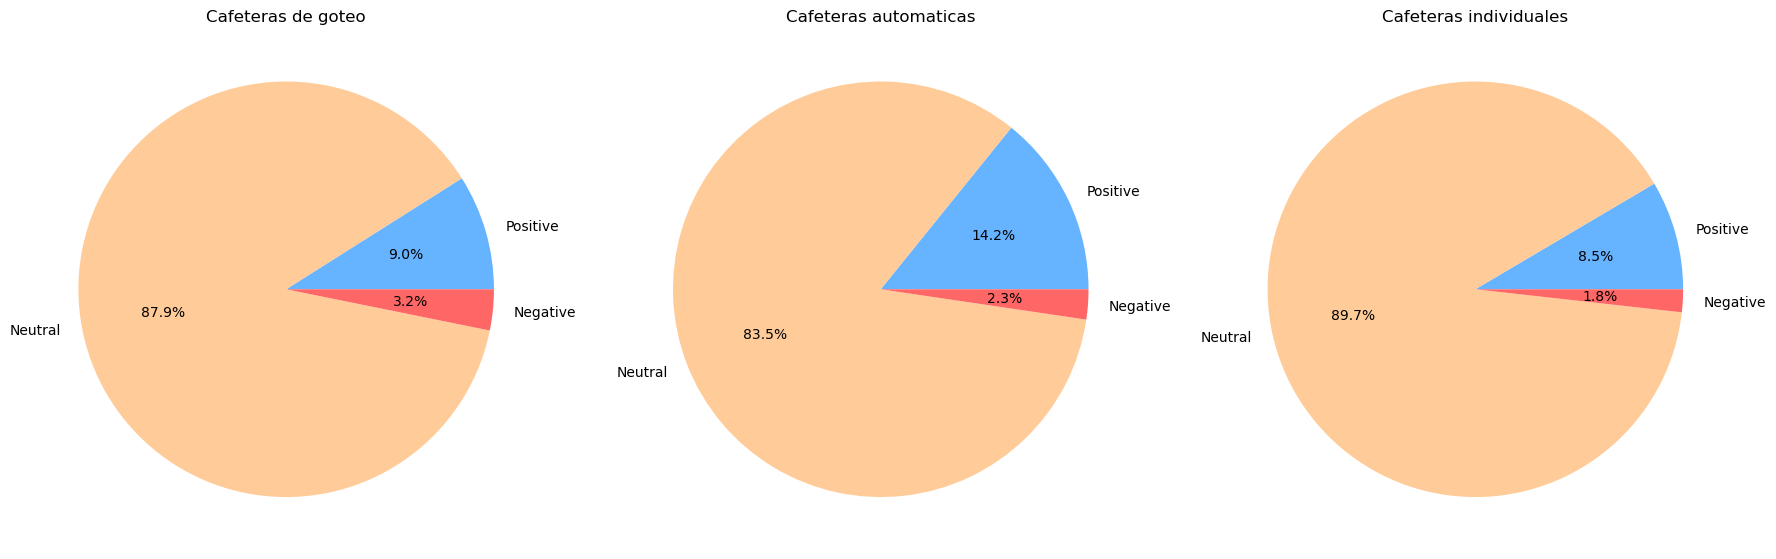

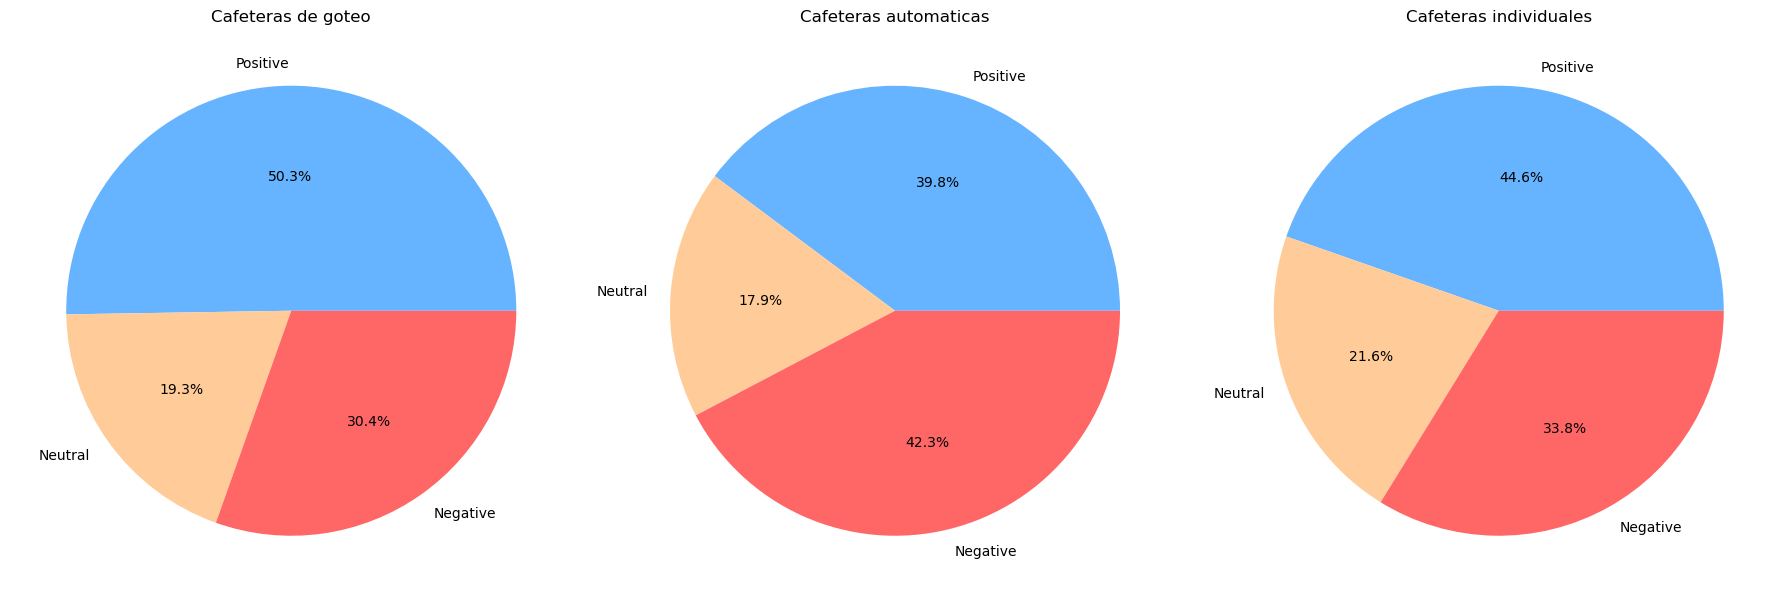

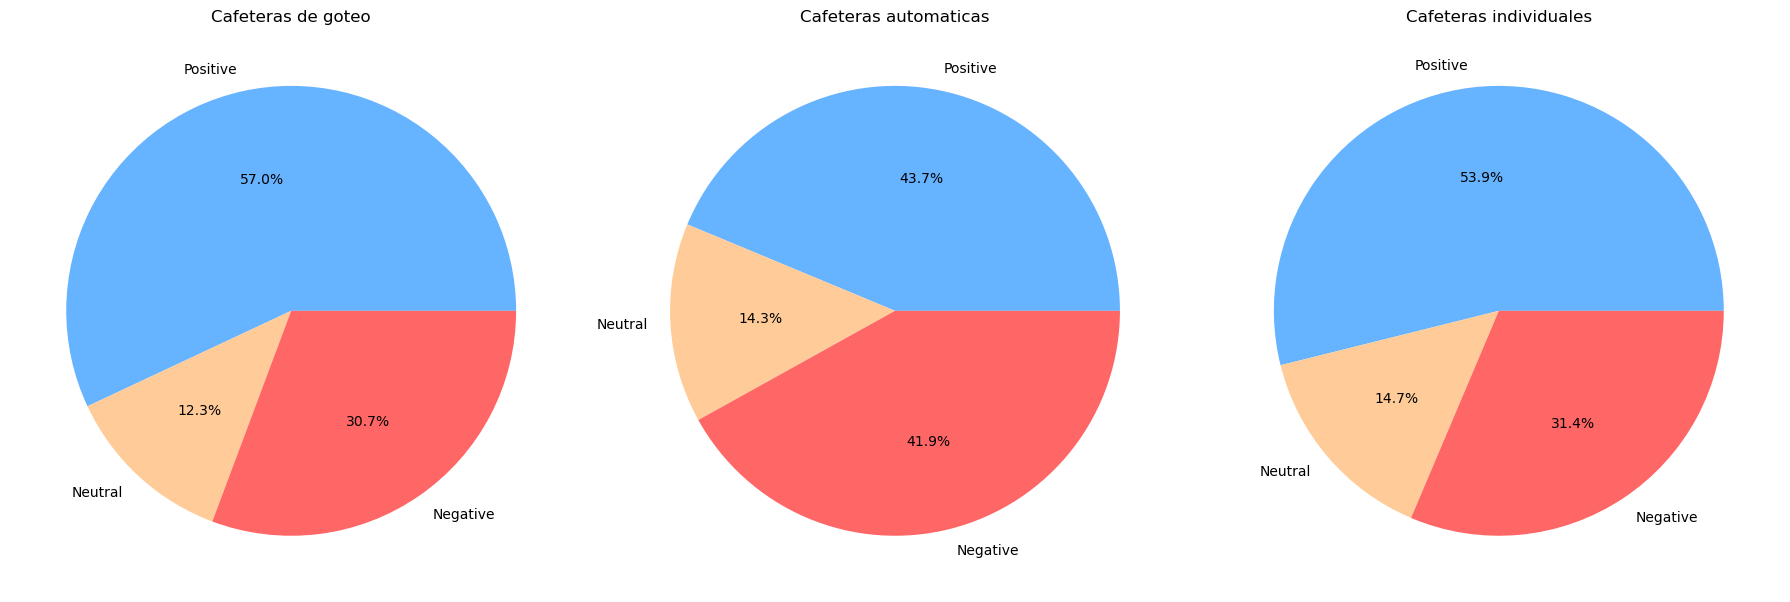

In [98]:
types = ['TextBlob_sentiment', 'Pysentimiento_sentiment', 'BERT_sentiment']

for i in range(3):
    polarities = load_polarities_from_csv(types[i])

    text = f'Result from {types[i]}:'
    html_code = f"""
    <b style="font-size: 20px;">
        <h1 style="font-size: 25px; text-align: center;">{text}</h1>
    </b>
    """
    display(HTML(html_code))

    show_pie_chart(polarities)
    

---
<b style="font-size: 20px;">
    Comparación de los enfoques
</b>

<p style="font-size: 18px;">Los resultados proporcionados por TextBlob parecen carecer presición</p>
<p style="font-size: 18px;  margin-top: -20px;">Comparación de los resultados de Pysentimiento y BERT</p>

In [118]:
show_comparison()

Review,Pysentimiento Sentiment,BERT Sentiment
"Después de más de dos meses usándola hace muy buen café, pero me parece que los materiales de la cafetera son malos muy plasticucha Y no sé el tiempo que durará la cafetera, pero para el valor que tiene podría tener unos materiales mejor. Por lo demás, muy muy bien hace un café estupendo",NEG,NEU
Un valle realmente bueno por el precio relativamente bajo.,NEU,POS
"Al principio funcionaba bien (menos el vaporizador que solo quema la leche y es tan complicado de limpiar que no lo utilizaba) Pero después de 2 años ya no tiene presión, tarda más de 5 minutos en llenar media taza de café, y para cuando la ha llenado el café ya está frío… no volvería a comprarla. Ahora me voy a comprar una que te has mayor presión y calidad, aunque sea más cara",NEU,NEG
Ha llegado roto,NEU,NEG
Si la temperatura es demasiado alta cosa que se consigue con el vaporizador.. el cafè sale por fuera del cacíllo.. si la temperatura és adequada hace un café buenísimo i és preciosa,POS,NEU


Review,Pysentimiento Sentiment,BERT Sentiment
"Función bastante bien con la salvedad del depósito para el café molido, que a veces no va bien y sale solo agua, perdiéndose el café",NEG,NEU
"La máquina está muy bien, pero ha llegado con una pieza rota. Cómo puedo reclamar para que me envíen otra igual? Gracias.",NEG,NEU
"Estoy contenta con la cafetera porque el café sale muy bueno pero me da problemas desde el primer día que la adquirí, es decir hace un mes y medio",NEG,NEU
"Excelente dispositivo, pero hace mucho ruido y hay que vaciarlo rápidamente.",NEG,POS
"No se el resultado que dará a la larga, pero de momento puedo decir que es una pasada de cafetera.",POS,NEG


Review,Pysentimiento Sentiment,BERT Sentiment
"Al usarla la encuentro extraordinariamente pequeña, solo para una taza pequeña. Ruego me informen cómo hago para cambiarla a otra de mayor capacidad. Espero sus noticias.",NEU,NEG
Diseño con estilo. Fácil de usar y vino con instrucciones buenas. Ocupa mucho menos espacio que la máquina que tenía antes. Pero un tamaño más pequeño significa que hay que vaciar las cápsulas antes (solo caben 5 más o menos).,NEU,POS
"De momento, y habiendo hecho 2 cafés solamente, es un pepinazo de cafetera. Pequeña con un diseño top. El azul es clarito, no tan fuerte como en la primera imagen. Hay que prestar atención la primera vez que se enchufa, seguir las instrucciones porque a mi no me salía agua al principio, dejé la ventana de la capsula abierta y cuando vi que empezaba a tirar agua la cerré, limpio el circuito y a funcionar.",NEU,POS
"Hola buenas, acabo de recibirlo y he tenido problemas al iniciar la cafetera por primera vez, AVISO!!!, LLENAR EL DEPÓSITO DE AGUA, he tardado un rato en ponerla en marcha, parecía que no cogía el agua y el error mío ha sido que tenía el depósito por la mitad, en cuanto lo he llenado hasta arriba se ha puesto ha funcionar, el producto es re acondicionado pero por el momento funcionamiento correcto",NEG,NEU
Las cápsulas son un poco caras y no son fácil de adquirir en los supermercados. Solo online pero el sabor de Lavazza a modo mio es buen café.,POS,NEU


---
<b style="font-size: 20px;">
    Comprobación de la precisión de todos los modelos (etiquetación manual)
</b>

<p style="font-size: 18px;">La mejor manera de evaluar la precisión de cada modelo es comparar sus resultados con las reseñas seleccionadas al azar y evaluadas de forma manual.</p>


In [15]:
# En primer lugar, es necesario seleccionar al azar reseñas de cada categoría en proporciones iguales.
def prepare_samples():
    
    SAMPLE_PERCENTAGE = 0.05  
    OUTPUT_FILE = 'new_database/analysis/sentiment_test_dataset.csv'

    dfs = []

    for i in range(3):
        file_path = f'new_database/analysis/analyzed_category_{i}.csv'

        df = pd.read_csv(file_path)
        df['category'] = i
        dfs.append(df)

    all_data = pd.concat(dfs, ignore_index = True)

    required_cols = ['body', 'TextBlob_sentiment', 'Pysentimiento_sentiment', 'BERT_sentiment']
    for col in required_cols:
        
        if col not in all_data.columns:
            raise ValueError(f"Column '{col}' not found")

    samples = []
    for category, group in all_data.groupby('category'):
        
        n = max(1, int(len(group) * SAMPLE_PERCENTAGE))
        sample = group.sample(n = n, random_state = 42)
        samples.append(sample)

    test_sample = pd.concat(samples, ignore_index =True)

    test_sample['Human_label'] = ''

    output_cols = ['category', 'body', 'TextBlob_sentiment', 'Pysentimiento_sentiment', 'BERT_sentiment', 'Human_label']
    test_sample = test_sample[output_cols]

    test_sample.to_csv(OUTPUT_FILE, index = False, encoding = 'utf-8')

if __name__ == "__main__":
    prepare_samples()


---

<b style="font-size: 20px;">Para agilizar el proceso, se ha creado una interfaz de usuario interactiva que permite al evaluador elegir entre tres opciones: POS, NEG o NEU.</b>

In [2]:
FILE_PATH = 'new_database/analysis/sentiment_test_dataset.csv'
df = pd.read_csv(FILE_PATH)
total = df.shape[0]

# global line index
current_index = None

output = widgets.Output()

# UI
def show_row(index):
    
    global current_index
    output.clear_output(wait = True)

    if index >= total or pd.isna(index):
        with output:
            print("All reviews sorted!")
        return

    row = df.loc[index]

    # Buttons
    pos_btn = widgets.Button(description = "POS", button_style ='success')
    neu_btn = widgets.Button(description = "NEU", button_style = 'info')
    neg_btn = widgets.Button(description = "NEG", button_style = 'danger')

    def on_click(label):
        
        def inner(_):
            
            global current_index
            df.at[index, 'Human_label'] = label
            df.to_csv(FILE_PATH, index = False, encoding = 'utf-8')

            next_unlabeled = df[(df['Human_label'].isna()) | (df['Human_label'] == '')]
            
            if next_unlabeled.empty:
                show_row(total)
            else:
                current_index = next_unlabeled.index.min()
                show_row(current_index)
                
        return inner

    pos_btn.on_click(on_click('POS'))
    neu_btn.on_click(on_click('NEU'))
    neg_btn.on_click(on_click('NEG'))

    with output:
        
        clear_output(wait = True)
        print(f"\nReview {index + 1} of {total} (Category ID: {row['category']})")
        print("-" * 60)
        print(row['body'])
        print("-" * 60)
        
        display(widgets.HBox([pos_btn, neu_btn, neg_btn]))

def main():
    
    global current_index

    unlabeled = df[(df['Human_label'].isna()) | (df['Human_label'] == '')]
    
    if unlabeled.empty:
        print("All reviews have already been sorted")
        return

    current_index = unlabeled.index.min()
    
    print(f"Total review count: {total}")
    print(f"Reviews remaining: {len(unlabeled)}")
    
    show_row(current_index)

if __name__ == "__main__":
    display(output)
    main()

Output()

All reviews have already been sorted


---

<b style="font-size: 20px;">Evaluando la precisión de los modelos</b>

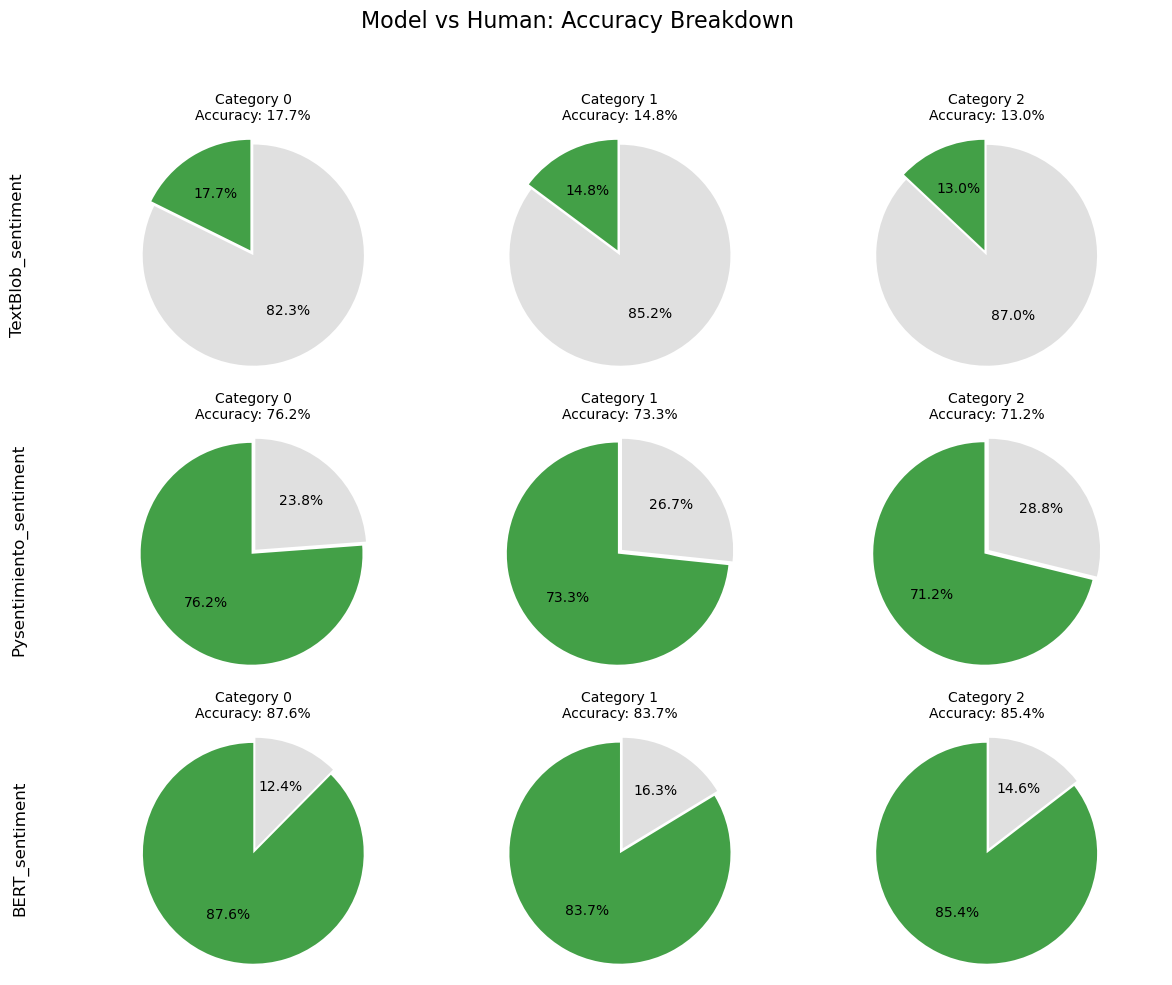

In [9]:
def show_pie_chart(ax, correct, incorrect): #ajustes para crear los gráficos circulares
    
    sizes = [correct, incorrect]
    colors = ['#43A047', '#E0E0E0']
    explode = (0.05, 0)

    ax.pie(
        sizes,
        explode = explode,
        autopct = '%1.1f%%',
        startangle = 90,
        colors = colors
    )
    ax.axis('equal')

if __name__ == "__main__": 

    df = pd.read_csv('new_database/analysis/sentiment_test_dataset.csv')
    types = ['TextBlob_sentiment', 'Pysentimiento_sentiment', 'BERT_sentiment']
    categories = sorted(df['category'].unique())

    fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (12, 10))
    fig.suptitle("Model vs Human: Accuracy Breakdown", fontsize=16)

    for row, model in enumerate(types):
        
        for col, cat in enumerate(categories):
            
            subset = df[df['category'] == cat]
            correct = (subset[model] == subset['Human_label']).sum()
            incorrect = len(subset) - correct
            accuracy = correct / (correct + incorrect) * 100

            ax = axes[row, col]
            show_pie_chart(ax, correct, incorrect)
            ax.set_title(f"Category {cat}\nAccuracy: {accuracy:.1f}%", fontsize = 10)

        axes[row, 0].text(-2.2, 0.0, types[row], fontsize = 12, rotation = 90, va = 'center')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

----
<p style="text-align: center; font-size: 25px; margin-top: 20px;">
    <strong>
          Modelado de temas: método Latent Dirichlet Allocation (LDA)
    </strong>
</p>

---

In [21]:
def preprocess(text):
    stop_words = set(stopwords.words('spanish'))
    additional_stop_words = ['bien', 'cafetera', 'máquina', 'si', 'do', 'hace', 'amazon', 'ademas', 'café', 'leche', 'cafe', 'agua']
    stop_words.update(additional_stop_words)

    lemmatizer = WordNetLemmatizer()
    words = word_tokenize(text.lower())
    words = [lemmatizer.lemmatize(word) for word in words if word.isalpha()]
    words = [word for word in words if word not in stop_words]

    return words

def preprocess_and_save(data, column, save_path):
    
    print("Starting preprocessing...")
    data['processed_body'] = data[column].apply(preprocess)
    data.to_csv(save_path, index=False)
    print(f"Preprocessed data saved at {save_path}")
    return data

def build_lda_models(corpus, dictionary, num_topics_list, passes= 15, iterations =200):
    
    lda_models = {}
    for num_topics in tqdm(num_topics_list, desc="Building LDA models"):
        lda_model = gensim.models.ldamodel.LdaModel(
            corpus=corpus,
            num_topics=num_topics,
            id2word=dictionary,
            passes=1,
            iterations=iterations
        )
        for _ in range(passes - 1):
            lda_model.update(corpus)
        lda_models[num_topics] = lda_model
    return lda_models

def calculate_coherence(lda_models, texts, dictionary, coherence_type='c_v'):
    coherence_scores = {}
    for num_topics, model in lda_models.items():
        coherence_model = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence=coherence_type
        )
        coherence_score = coherence_model.get_coherence()
        coherence_scores[num_topics] = coherence_score
        #print(f"Coherence score for {num_topics} topics: {coherence_score:.4f}")
    return coherence_scores

def plot_coherence_scores(coherence_scores, save_path):
    num_topics = list(coherence_scores.keys())
    scores = list(coherence_scores.values())

    plt.figure(figsize=(10, 5))
    plt.plot(num_topics, scores, marker='o', linestyle='-')
    plt.title('Coherence Score by Number of Topics')
    plt.xlabel('Number of Topics')
    plt.ylabel('Coherence Score')
    plt.grid(True)
    plt.savefig(save_path)
    plt.close()

def save_filtered_topics(lda_model, coherence_score, threshold, save_path, num_words=10):
    if coherence_score >= threshold:
        topics = lda_model.show_topics(num_words=num_words, formatted=False)
        data = {
            f'Topic {i}': [f"{word} ({prob:.4f})" for word, prob in topic]
            for i, topic in topics
        }
        df = pd.DataFrame(data)
        df.to_csv(save_path, index=False)
        print(f"Filtered topics saved at {save_path}")
    else:
        print(f"Model coherence score ({coherence_score:.4f}) below threshold ({threshold}). Topics not saved.")

def calculate_coherence_and_save(lda_models, texts, dictionary, save_path, coherence_type='c_v'):
    coherence_scores = []
    for num_topics, model in lda_models.items():
        coherence_model = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence=coherence_type
        )
        coherence_score = coherence_model.get_coherence()
        coherence_scores.append({'num_topics': num_topics, 'coherence_score': coherence_score})
    
    coherence_df = pd.DataFrame(coherence_scores)
    coherence_df.to_csv(save_path, index=False)
    print(f"Coherence scores saved at {save_path}")
    
    return {row['num_topics']: row['coherence_score'] for row in coherence_scores}


def save_best_model(lda_models, best_num_topics, save_path):
    best_model = lda_models[best_num_topics]
    best_model.save(save_path)
    print(f"Best model with {best_num_topics} topics saved at {save_path}")

def main():
    start_time = time.perf_counter()

    input_folder = 'new_database/analysis'
    output_folder = 'new_database/analysis/LDA/processed'
    os.makedirs(output_folder, exist_ok=True)

    num_topics_list = range(1, 21) 
    coherence_threshold = 0.3

    for category_num in range(3):
        input_file = os.path.join(input_folder, f'category_{category_num}.csv')
        output_file = os.path.join(output_folder, f'processed_category_{category_num}.csv')

        data = pd.read_csv(input_file)
        processed_data = preprocess_and_save(data, 'body', output_file)

        dictionary = corpora.Dictionary(processed_data['processed_body'])
        corpus = [dictionary.doc2bow(text) for text in processed_data['processed_body']]

        lda_models = build_lda_models(corpus, dictionary, num_topics_list)
        
        coherence_path = os.path.join(output_folder, f'coherence_scores_category_{category_num}.csv')
        coherence_scores = calculate_coherence_and_save(lda_models, processed_data['processed_body'], dictionary, coherence_path)

        best_num_topics = max(coherence_scores, key=coherence_scores.get)
        best_model_path = os.path.join(input_folder, f'LDA/tuned_models/best_model_category_{category_num}.model')
        save_best_model(lda_models, best_num_topics, best_model_path)
        
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"Time taken: {datetime.timedelta(seconds=elapsed_time)}")

if __name__ == "__main__":
    main()


Starting preprocessing...
Preprocessed data saved at new_database/analysis/LDA/processed/processed_category_0.csv


Building LDA models: 100%|██████████████████████| 20/20 [17:47<00:00, 53.40s/it]


Coherence scores saved at new_database/analysis/LDA/processed/coherence_scores_category_0.csv
Best model with 7 topics saved at new_database/analysis/LDA/tuned_models/best_model_category_0.model
Starting preprocessing...
Preprocessed data saved at new_database/analysis/LDA/processed/processed_category_1.csv


Building LDA models: 100%|██████████████████████| 20/20 [15:00<00:00, 45.00s/it]


Coherence scores saved at new_database/analysis/LDA/processed/coherence_scores_category_1.csv
Best model with 3 topics saved at new_database/analysis/LDA/tuned_models/best_model_category_1.model
Starting preprocessing...
Preprocessed data saved at new_database/analysis/LDA/processed/processed_category_2.csv


Building LDA models: 100%|██████████████████████| 20/20 [14:14<00:00, 42.70s/it]


Coherence scores saved at new_database/analysis/LDA/processed/coherence_scores_category_2.csv
Best model with 4 topics saved at new_database/analysis/LDA/tuned_models/best_model_category_2.model
Time taken: 0:57:58.614087


---
<b style="font-size: 20px;">
    Mostrando los resultados obtenidos mediante el modelo LDA 
</b>

<p style="font-size: 18px;">Resumen de los resultados</p>

In [37]:
def save_lda_topics_from_best_models(model_path, file_name, num_words=10):

    try:
        lda_model = gensim.models.LdaModel.load(model_path)
        
        topics = lda_model.show_topics(num_topics=lda_model.num_topics, num_words=num_words, formatted=False)
        
        data = {}
        for topic_num, words in topics:
            sorted_words = sorted(words, key=lambda x: x[1], reverse=True)
            
            topic_representation = [f"{word} ({prob:.4f})" for word, prob in sorted_words]
            data[f"Topic {topic_num}"] = topic_representation
        
        df = pd.DataFrame(data)
        df.to_csv(file_name, index=False)
        #Topics saved successfully at {file_name}
    
    except FileNotFoundError:
        print(f"Model not found at {model_path}. Skipping this category.")

def save_topics_for_best_models():

    tuned_models_folder = 'new_database/analysis/LDA/tuned_models'
    output_folder = 'new_database/analysis/LDA/topics'
    os.makedirs(output_folder, exist_ok=True)

    for category_num in range(3):
        model_path = os.path.join(tuned_models_folder, f'best_model_category_{category_num}.model')
        
        topics_file = os.path.join(output_folder, f'new_LDA_category_{category_num}.csv')
        
        save_lda_topics_from_best_models(model_path, topics_file)

def parse_word_probability(cell_value):
    match = re.match(r'(\S+) \(([\d.]+)\)', cell_value)
    if match:
        return match.group(1), float(match.group(2))
    else:
        return None, None

def load_topics_LDA(file_name):
    df = pd.read_csv(file_name)
    topic_word_freq = {}

    for col in df.columns:
        if col.startswith('Topic '):
            word_freq = {}
            for cell_value in df[col].dropna():
                word, probability = parse_word_probability(cell_value)
                if word is not None and probability is not None:
                    word_freq[word] = probability
            topic_word_freq[col] = word_freq

    return topic_word_freq

def save_wordcloud_LDA(word_freq, category_index, topic_index, output_folder='assets'):
    
    os.makedirs(output_folder, exist_ok=True)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
    image_path = f'{output_folder}/LDA_category_{category_index}_topic_{topic_index}.png'
    wordcloud.to_file(image_path)
    return image_path

def generate_wordcloud_html(topic_word_freqs, category_name, category_index, output_folder='assets'):

    os.makedirs(output_folder, exist_ok=True)
    html_code = f"<h1 style='text-align: center;'>{category_name}</h1><div style='display: flex; flex-wrap: wrap; justify-content: center;'>"

    for topic_index, (topic_name, word_freq) in enumerate(topic_word_freqs.items()):
        image_path = save_wordcloud_LDA(word_freq, category_index, topic_index, output_folder)
        html_code += f"""
        <div style="flex: 1 0 30%; margin: 10px; text-align: center;">
            <h3>{topic_name}</h3>
            <img src="{image_path}" alt="WordCloud for {topic_name}" style="width: 100%; max-width: 300px;">
        </div>
        """

    html_code += "</div><hr style='border: 1px solid gray; margin: 20px 0;'>"
    return html_code

def generate_visualizations(categories, lda_folder='new_database/analysis/LDA/topics', output_folder='assets'):
    html_content = "<h1 style='text-align: center;'>LDA Results</h1><div style='width: 90%; margin: 0 auto;'>"
    
    for i, category_name in enumerate(categories):
        csv_path = f'{lda_folder}/new_LDA_category_{i}.csv'
        topic_word_freqs = load_topics_LDA(csv_path)
        html_content += generate_wordcloud_html(topic_word_freqs, category_name, i, output_folder)
    
    html_content += "</div>"
    
    os.makedirs(output_folder, exist_ok=True)
    html_file_path = f'{output_folder}/lda_results.html'
    with open(html_file_path, 'w', encoding='utf-8') as file:
        file.write(html_content)
    
    display(HTML(html_content))

def get_category_names(base_csv='new_database/base.csv'):
    base_df = pd.read_csv(base_csv)
    return base_df['category'].tolist()

if __name__ == "__main__":
    save_topics_for_best_models()
    
    category_names = get_category_names()
    
    generate_visualizations(category_names)


---
<b style="font-size: 20px;">
    Mostrando los temas extraídos dentro de cada categoría en formato de tablas
</b>

In [72]:
def display_all_topic_tables(output_folder, categories):

    html_content = """
    <html>
    <head>
        <style>
            body { font-family: Arial, sans-serif; margin: 0; padding: 0; }
            table { border-collapse: collapse; width: 90%; margin: 20px auto; }
            th, td { text-align: left; padding: 8px; border: 1px solid #ddd; }
            th { background-color: #f2f2f2; }
            tr:nth-child(even) { background-color: #f9f9f9; }
            tr:hover { background-color: #f1f1f1; }
            .header { text-align: center; margin: 20px 0; }
        </style>
    </head>
    <body>
    """

    for i, category in enumerate(categories):
        file_path = os.path.join(output_folder, f'new_LDA_category_{i}.csv')
        
        if not os.path.exists(file_path):
            print(f"File {file_path} does not exist. Skipping.")
            continue

        topics_df = pd.read_csv(file_path)

        html_content += f"""
        <div class="header">
            <h2>{category}</h2>
        </div>
        <div>
            {topics_df.to_html(index=False, escape=False)}
        </div>
        <hr style="border: 1px solid gray; width: 90%; margin: 20px auto;">
        """

    html_content += """
    </body>
    </html>
    """
    
    display(HTML(html_content))

if __name__ == "__main__":
    output_folder = 'new_database/analysis/LDA/topics'
    categories = get_category_names()

    display_all_topic_tables(output_folder, categories)


Topic 0,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6
jarra (0.0292),espuma (0.0293),después (0.0124),calidad (0.0522),fácil (0.0420),filtro (0.0112),jarra (0.0163)
filtro (0.0158),hacer (0.0158),producto (0.0116),buena (0.0324),buen (0.0332),tazas (0.0089),caliente (0.0141)
posos (0.0105),sale (0.0155),años (0.0092),precio (0.0244),usar (0.0249),hacer (0.0073),filtro (0.0099)
ma (0.0103),bueno (0.0108),uso (0.0092),parece (0.0142),buena (0.0215),jarra (0.0066),tazas (0.0082)
cristal (0.0092),calentar (0.0103),día (0.0091),producto (0.0124),limpiar (0.0203),gusta (0.0064),tiempo (0.0080)
acero (0.0082),cafés (0.0098),funciona (0.0088),termo (0.0112),compra (0.0149),aunque (0.0062),hacer (0.0078)
sale (0.0078),caliente (0.0092),cecotec (0.0086),materiales (0.0102),funciona (0.0139),puede (0.0060),sale (0.0072)
toda (0.0070),solo (0.0090),funcionar (0.0086),plástico (0.0095),calidad (0.0137),goteo (0.0058),inducción (0.0071)
parte (0.0067),usar (0.0085),marca (0.0082),cumple (0.0079),diseño (0.0128),depósito (0.0058),bastante (0.0069)
menos (0.0066),calienta (0.0085),servicio (0.0082),relación (0.0079),precio (0.0119),sale (0.0057),puede (0.0066)


---
<b style="font-size: 20px;">
    Contando el índice de coherencia (Coherence Score)
</b>

In [10]:
def display_html_with_graphics(category_num, output_folder, categories):

    graph_path = os.path.join(output_folder, f'coherence_scores_category_{category_num}.png')
    coherence_file = os.path.join(output_folder, f'coherence_scores_category_{category_num}.csv')
    coherence_data = pd.read_csv(coherence_file)
    plt.figure(figsize=(10, 5))
    plt.plot(coherence_data['num_topics'], coherence_data['coherence_score'], marker='o', linestyle='-')
    plt.title('Coherence Score by Number of Topics')
    plt.xlabel('Number of Topics')
    plt.ylabel('Coherence Score')
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid(True)
    plt.savefig(graph_path)
    plt.close()
    
    html_code = f"""
    <div style="text-align: center; margin: 20px 0;">
        <h2>{categories[category_num]}</h2>
        <img src="{graph_path}" alt="Coherence Scores" style="width: 80%; margin: 0 auto; display: block;">
    </div>
    <hr style="border: 1px solid gray; width: 90%; margin: 20px auto;">
    """
    
    display(HTML(html_code))

def get_names():
    base_df = pd.read_csv('new_database/base.csv')  
    categories = []

    for ID in base_df['ID']:
        category = base_df.loc[base_df['ID'] == ID, 'category'].values[0]
        categories.append(category)

    return categories 

if __name__ == "__main__":   
    
    output_folder = 'new_database/analysis/LDA/processed'
    categories = get_names()

    for category_num in range(3):
        display_html_with_graphics(category_num, output_folder, categories)


----
<p style="text-align: center; font-size: 25px; margin-top: 20px;">
    <strong>
          Modelado de temas: método Latent Semantic Analysis (LSA)
    </strong>
</p>

---

In [32]:
def preprocess(text):
    stop_words = set(stopwords.words('spanish'))
    additional_stop_words = ['bien', 'cafetera', 'máquina', 'si', 'do', 'hace', 'amazon', 'ademas', 'café', 'leche', 'cafe', 'agua', 'buena']
    stop_words.update(additional_stop_words)

    lemmatizer = WordNetLemmatizer()
    words = word_tokenize(text.lower())
    words = [lemmatizer.lemmatize(word) for word in words if word.isalpha()]
    words = [word for word in words if word not in stop_words]

    return words


def calculate_coherence_and_save_lsa(lsa_models, texts, dictionary, save_path, vectorizer):
    coherence_scores = []
    words = vectorizer.get_feature_names_out()
    
    for num_topics, model in lsa_models.items():

        topics = []
        for topic_idx in range(model.components_.shape[0]):
            top_indices = model.components_[topic_idx].argsort()[-10:][::-1]  # Top 10 words
            topics.append([words[i] for i in top_indices])
        
        coherence_model = CoherenceModel(
            topics=topics,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        coherence_score = coherence_model.get_coherence()
        coherence_scores.append({'num_topics': num_topics, 'coherence_score': coherence_score})
    
    coherence_df = pd.DataFrame(coherence_scores)
    coherence_df.to_csv(save_path, index=False)
    print(f"Coherence scores saved at {save_path}")
    
    return {row['num_topics']: row['coherence_score'] for row in coherence_scores}



def save_best_model_lsa(lsa_model, vectorizer, save_folder, category_num):
    os.makedirs(save_folder, exist_ok=True)
    model_path = os.path.join(save_folder, f'best_model_category_{category_num}.pkl')
    vectorizer_path = os.path.join(save_folder, f'best_vectorizer_category_{category_num}.pkl')
    
    with open(model_path, 'wb') as f:
        pickle.dump(lsa_model, f)
    with open(vectorizer_path, 'wb') as f:
        pickle.dump(vectorizer, f)
    
    print(f"Best LSA model and vectorizer for category {category_num} saved at {save_folder}")


def main():
    start_time = time.perf_counter()

    input_folder = 'new_database/analysis'
    output_folder = 'new_database/analysis/LSA/processed'
    os.makedirs(output_folder, exist_ok=True)

    num_topics_list = range(1, 21)
    for category_num in range(3):
        input_file = os.path.join(input_folder, f'category_{category_num}.csv')
        output_file = os.path.join(output_folder, f'processed_category_{category_num}.csv')

        data = pd.read_csv(input_file)
        print(f"Processing category {category_num}...")

        data['processed_body'] = data['body'].apply(lambda x: ' '.join(preprocess(x)))
        data.to_csv(output_file, index=False)
        print(f"Processed data saved to {output_file}")

        vectorizer = TfidfVectorizer(max_features=1000)
        tfidf_matrix = vectorizer.fit_transform(data['processed_body'])
        
        tokenized_texts = [preprocess(text) for text in data['body']]
        dictionary = Dictionary(tokenized_texts)

        lsa_models = {}
        for num_topics in tqdm(num_topics_list, desc=f"Training LSA models for category {category_num}"):
            lsa_model = TruncatedSVD(n_components=num_topics, n_iter=100, random_state=42)
            lsa_model.fit(tfidf_matrix)
            lsa_models[num_topics] = lsa_model

        coherence_path = os.path.join(output_folder, f'coherence_scores_category_{category_num}.csv')
        coherence_scores = calculate_coherence_and_save_lsa(
            lsa_models, 
            tokenized_texts, 
            dictionary, 
            coherence_path, 
            vectorizer  
        )

        best_num_topics = max(coherence_scores, key=coherence_scores.get)
        best_model = lsa_models[best_num_topics]
        best_model_folder = os.path.join(output_folder, 'tuned_models')
        save_best_model_lsa(best_model, vectorizer, best_model_folder, category_num)

    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"Time taken: {datetime.timedelta(seconds = elapsed_time)}")


if __name__ == "__main__":
    main()


Processing category 0...
Processed data saved to new_database/analysis/LSA/processed/processed_category_0.csv


Training LSA models for category 0: 100%|███████| 20/20 [00:20<00:00,  1.02s/it]


Coherence scores saved at new_database/analysis/LSA/processed/coherence_scores_category_0.csv
Best LSA model and vectorizer for category 0 saved at new_database/analysis/LSA/processed/tuned_models
Processing category 1...
Processed data saved to new_database/analysis/LSA/processed/processed_category_1.csv


Training LSA models for category 1: 100%|███████| 20/20 [00:20<00:00,  1.03s/it]


Coherence scores saved at new_database/analysis/LSA/processed/coherence_scores_category_1.csv
Best LSA model and vectorizer for category 1 saved at new_database/analysis/LSA/processed/tuned_models
Processing category 2...
Processed data saved to new_database/analysis/LSA/processed/processed_category_2.csv


Training LSA models for category 2: 100%|███████| 20/20 [00:18<00:00,  1.11it/s]


Coherence scores saved at new_database/analysis/LSA/processed/coherence_scores_category_2.csv
Best LSA model and vectorizer for category 2 saved at new_database/analysis/LSA/processed/tuned_models
Time taken: 0:12:07.121456


---
<b style="font-size: 20px;">
    Mostrando los resultados obtenidos mediante LSA
</b>

In [35]:
def save_lsa_topics_from_best_models(model_path, vectorizer_path, file_name, num_words = 10):
    try:
        with open(model_path, 'rb') as f:
            lsa_model = pickle.load(f)
        with open(vectorizer_path, 'rb') as f:
            vectorizer = pickle.load(f)
        
        words = vectorizer.get_feature_names_out()
        topics = {}
        
        for topic_idx, component in enumerate(lsa_model.components_):
            
            top_indices = component.argsort()[-num_words:][::-1]
            topic_words = [(words[i], component[i]) for i in top_indices]
            topics[f"Topic {topic_idx}"] = topic_words

        data = {}
        for topic_name, word_list in topics.items():
            
            topic_representation = [f"{word} ({weight:.4f})" for word, weight in word_list]
            data[topic_name] = topic_representation

        df = pd.DataFrame(data)
        df.to_csv(file_name, index=False)
        #print(f"Topics saved successfully at {file_name}")

    except FileNotFoundError:
        print(f"Model or vectorizer not found at {model_path} or {vectorizer_path}. Skipping this category.")


def save_topics_for_best_lsa_models():

    tuned_models_folder = 'new_database/analysis/LSA/processed/tuned_models'
    output_folder = 'new_database/analysis/LSA/topics'
    os.makedirs(output_folder, exist_ok=True)

    for category_num in range(3):
        model_path = os.path.join(tuned_models_folder, f'best_model_category_{category_num}.pkl')
        vectorizer_path = os.path.join(tuned_models_folder, f'best_vectorizer_category_{category_num}.pkl')
        topics_file = os.path.join(output_folder, f'new_LSA_category_{category_num}.csv')
        
        save_lsa_topics_from_best_models(model_path, vectorizer_path, topics_file)


def parse_word_probability(cell_value):
    match = re.match(r'(\S+) \(([\d.]+)\)', cell_value)
    if match:
        return match.group(1), float(match.group(2))
    else:
        return None, None


def load_topics_lsa(file_name):
    
    df = pd.read_csv(file_name)
    topic_word_freq = {}

    for col in df.columns:
        if col.startswith('Topic '):
            word_freq = {}
            for cell_value in df[col].dropna():
                
                word, weight = parse_word_probability(cell_value)
                if word is not None and weight is not None:
                    word_freq[word] = weight
            topic_word_freq[col] = word_freq

    return topic_word_freq


def save_wordcloud_lsa(word_freq, category_index, topic_index, output_folder='assets'):
    os.makedirs(output_folder, exist_ok = True)
    wordcloud = WordCloud(width = 800, height = 400, background_color ='white').generate_from_frequencies(word_freq)
    
    image_path = f'{output_folder}/LSA_category_{category_index}_topic_{topic_index}.png'
    wordcloud.to_file(image_path)
    return image_path


def generate_wordcloud_html(topic_word_freqs, category_name, category_index, output_folder='assets'):

    os.makedirs(output_folder, exist_ok=True)
    html_code = f"<h1 style='text-align: center;'>{category_name}</h1><div style='display: flex; flex-wrap: wrap; justify-content: center;'>"

    for topic_index, (topic_name, word_freq ) in enumerate(topic_word_freqs.items()):
        image_path = save_wordcloud_lsa(word_freq, category_index, topic_index, output_folder)
        html_code += f"""
        <div style="flex: 1 0 30%; margin: 10px; text-align: center;">
            <h3>{topic_name}</h3>
            <img src="{image_path}" alt="WordCloud for {topic_name}" style="width: 100%; max-width: 300px;">
        </div>
        """

    html_code += "</div><hr style='border: 1px solid gray; margin: 20px 0;'>"
    return html_code


def generate_visualizations(categories, lsa_folder='new_database/analysis/LSA/topics', output_folder='assets'):

    html_content = "<h1 style='text-align: center;'>LSA Results</h1><div style='width: 90%; margin: 0 auto;'>"
    
    for i, category_name in enumerate(categories):
        csv_path = f'{lsa_folder}/new_LSA_category_{i}.csv'
        topic_word_freqs = load_topics_lsa(csv_path)
        html_content += generate_wordcloud_html(topic_word_freqs, category_name, i, output_folder)
    
    html_content += "</div>"
    
    os.makedirs(output_folder, exist_ok=True)
    
    html_file_path = f'{output_folder}/lsa_results.html'
    with open(html_file_path, 'w', encoding='utf-8') as file:
        
        file.write(html_content)
    
    display(HTML(html_content))


def get_category_names(base_csv='new_database/base.csv'):
    base_df = pd.read_csv(base_csv)
    return base_df['category'].tolist()


if __name__ == "__main__":
    save_topics_for_best_lsa_models()
    
    category_names = get_category_names()
    
    generate_visualizations(category_names)


---
<b style="font-size: 20px;">
    Mostrando los temas extraídos dentro de cada categoría en formato de tablas
</b>

In [77]:
def display_all_topic_tables_LSA(output_folder, categories):

    html_content = """
    <html>
    <head>
        <style>
            body { font-family: Arial, sans-serif; margin: 0; padding: 0; }
            table { border-collapse: collapse; margin: 20px auto; }
            th, td { text-align: left; padding: 8px; border: 1px solid #ddd; }
            th { background-color: #f2f2f2; }
            tr:nth-child(even) { background-color: #f9f9f9; }
            tr:hover { background-color: #f1f1f1; }
            .header { text-align: center; margin: 20px 0; }
        </style>
    </head>
    <body>
    """

    for i, category in enumerate(categories):
        file_path = os.path.join(output_folder, f'new_LSA_category_{i}.csv')
        
        if not os.path.exists(file_path):
            print(f"File {file_path} does not exist. Skipping.")
            continue

        topics_df = pd.read_csv(file_path)
        
        num_columns = len(topics_df.columns)
        table_width = f"width: {max(50, min(90, num_columns * 10))}%;"

        html_content += f"""
        <div class="header">
            <h2>{category}</h2>
        </div>
        <div>
            <table style="{table_width}">
                {topics_df.to_html(index=False, escape = False, header = True)}
            </table>
        </div>
        <hr style="border: 1px solid gray; width: 90%; margin: 20px auto;">
        """

    html_content += """
    </body>
    </html>
    """

    display(HTML(html_content))

if __name__ == "__main__":
    
    output_folder = 'new_database/analysis/LSA/topics'
    categories = get_category_names()

    display_all_topic_tables_LSA(output_folder, categories)

Topic 0,Topic 1
calidad (0.2873),calidad (0.5622)
fácil (0.2750),precio (0.3901)
buen (0.2645),relación (0.1425)
precio (0.2231),producto (0.1279)
usar (0.2097),buen (0.0933)
sale (0.1661),excelente (0.0461)
limpiar (0.1546),mala (0.0446)
funciona (0.1494),materiales (0.0409)
producto (0.1487),cumple (0.0260)
bueno (0.1250),plástico (0.0218)


---
<b style="font-size: 20px;">
    Contanto el índice de coherencia (Coherence Score)
</b>

In [11]:
def display_html_with_graphics_and_topics_lsa(category_num, output_folder, categories):

    graph_path = os.path.join(output_folder, f'lsa_coherence_category_{category_num}.png')

    coherence_file = os.path.join(output_folder, f'processed/coherence_scores_category_{category_num}.csv')
    coherence_data = pd.read_csv(coherence_file)
    
    plt.figure(figsize=(10, 5))
    plt.plot(coherence_data['num_topics'], coherence_data['coherence_score'], marker='o', linestyle='-')
    plt.title('Coherence Score by Number of Topics (LSA)')
    plt.xlabel('Number of Topics')
    plt.ylabel('Coherence Score')
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer= True))
    plt.grid(True)
    plt.savefig(graph_path)
    plt.close()
    
    html_code = f"""
    <div style="text-align: center; margin: 20px 0;">
        <h2>{categories[category_num]}</h2>
        <img src="{graph_path}" alt="Coherence Scores" style="width: 80%; margin: 0 auto; display: block;">
    </div>
    <hr style="border: 1px solid gray; width: 90%; margin: 20px auto;">
    """
    display(HTML(html_code))

def get_names():
    base_df = pd.read_csv('new_database/base.csv')  
    categories = base_df['category'].tolist()
    return categories 

if __name__ == "__main__":
    output_folder = 'new_database/analysis/LSA'
    categories = get_names()

    for category_num in range(3):
        display_html_with_graphics_and_topics_lsa(category_num, output_folder, categories)

---
<b style="font-size: 20px;">
    Comparación de los resultados obtenidos por modelos LDA y LSA
</b>

In [83]:
def get_category_names(base_csv='new_database/base.csv'):
    
    base_df = pd.read_csv(base_csv)
    return base_df['category'].tolist()


def create_html_table_with_combined_rows(csv_file, html_output_file, category_name, top_n = 5):
    df = pd.read_csv(csv_file)
    df = df.drop_duplicates()
    df = df.drop(columns=[df.columns[1]]) 
    df = df.head(top_n * 2)

    combined_data = []
    for i in range(0, len(df), 2):
        if i + 1 >= len(df):
            break

        lda_row = df.iloc[i].values
        lsa_row = df.iloc[i + 1].values

        combined_row = ["LDA/LSA"] + [f"{lda} / {lsa}" for lda, lsa in zip(lda_row[1:], lsa_row[1:])]
        combined_data.append(combined_row)

    num_columns = len(combined_data[0]) if combined_data else 0
    column_names = ["Method"] + [f"Word {i+1}" for i in range(num_columns - 1)]

    combined_df = pd.DataFrame(combined_data, columns=column_names)

    html_content = f"""
    <html>
    <head>
        <style>
            body {{ font-family: Arial, sans-serif; margin: 0; padding: 0; }}
            table {{ border-collapse: collapse; width: 100%; margin: 20px 0; }}
            th, td {{ text-align: left; padding: 8px; }}
            th {{ background-color: #f2f2f2; }}
            tr:nth-child(even) {{ background-color: #f9f9f9; }}
            tr:hover {{ background-color: #f1f1f1; }}
            .header {{ text-align: center; margin: 20px 0; }}
        </style>
    </head>
    <body>
        <div class="header">
            <h1>Comparison of LSA and LDA Topics for Category: {category_name}</h1>
        </div>
        <table border="1">
    """
    html_content += combined_df.to_html(index = False, escape =False, header= True)
    html_content += """
        </table>
    </body>
    </html>
    """

    with open(html_output_file, 'w', encoding='utf-8') as file:
        file.write(html_content)

    display(HTML(html_content))



if __name__ == "__main__":
    
    category_names = get_category_names()
    
    for i, category_name in enumerate(category_names): 
        lsa_file_name = f'new_database/analysis/LSA/topics/new_LSA_category_{i}.csv'
        lda_file_name = f'new_database/analysis/LDA/topics/new_LDA_category_{i}.csv'
        output_csv_file = f'new_database/analysis/comparison_LSA_LDA_category_{i}.csv'
        html_output_file = f'new_database/analysis/comparison_LSA_LDA_category_{i}.html'
        
        top_n = 5 
        
        create_comparison_table(lsa_file_name, lda_file_name, output_csv_file, top_n)
        
        create_html_table_with_combined_rows(output_csv_file, html_output_file, category_name, top_n)


Method,Word 1,Word 2,Word 3,Word 4,Word 5,Word 6,Word 7,Word 8,Word 9,Word 10
LDA/LSA,fácil (0.0420) / fácil (0.2750),buen (0.0332) / buen (0.2645),usar (0.0249) / usar (0.2097),limpiar (0.0203) / limpiar (0.1546),funciona (0.0139) / funciona (0.1494),calidad (0.0137) / calidad (0.2873),precio (0.0119) / precio (0.2231),buena (0.0215) / sale (0.1661),compra (0.0149) / producto (0.1487),diseño (0.0128) / bueno (0.1250)
LDA/LSA,calidad (0.0522) / calidad (0.5622),precio (0.0244) / precio (0.3901),producto (0.0124) / producto (0.1279),materiales (0.0102) / materiales (0.0409),plástico (0.0095) / plástico (0.0218),relación (0.0079) / relación (0.1425),cumple (0.0079) / cumple (0.0260),buena (0.0324) / buen (0.0933),parece (0.0142) / excelente (0.0461),termo (0.0112) / mala (0.0446)


Method,Word 1,Word 2,Word 3,Word 4,Word 5,Word 6,Word 7,Word 8,Word 9,Word 10
LDA/LSA,sale (0.0171) / sale (0.1884),hacer (0.0105) / hacer (0.1529),buen (0.0092) / buen (0.2014),cafés (0.0073) / cafés (0.1307),usar (0.0057) / usar (0.1431),bueno (0.0085) / fácil (0.1497),espuma (0.0066) / calidad (0.1425),buena (0.0058) / precio (0.1280),caliente (0.0055) / cada (0.1247),mejor (0.0054) / uso (0.1233)


Method,Word 1,Word 2,Word 3,Word 4,Word 5,Word 6,Word 7,Word 8,Word 9,Word 10
LDA/LSA,cápsulas (0.0274) / cápsulas (0.3026),fácil (0.0248) / fácil (0.3039),usar (0.0225) / usar (0.2807),precio (0.0180) / precio (0.2198),buen (0.0137) / buen (0.2085),gusta (0.0107) / gusta (0.1431),bueno (0.0106) / bueno (0.1264),sale (0.0100) / sale (0.1642),cafés (0.0098) / funciona (0.1836),marca (0.0097) / calidad (0.1678)
LDA/LSA,fácil (0.0248) / fácil (0.6589),usar (0.0225) / usar (0.5428),cápsulas (0.0274) / limpiar (0.1171),precio (0.0180) / facil (0.0466),buen (0.0137) / práctica (0.0353),gusta (0.0107) / cómoda (0.0329),bueno (0.0106) / ocupa (0.0278),sale (0.0100) / practica (0.0243),cafés (0.0098) / espacio (0.0226),marca (0.0097) / manejo (0.0194)
LDA/LSA,precio (0.0180) / precio (0.4587),buen (0.0137) / buen (0.5553),cápsulas (0.0274) / calidad (0.3837),fácil (0.0248) / producto (0.2057),usar (0.0225) / relación (0.0595),gusta (0.0107) / cumple (0.0290),bueno (0.0106) / excelente (0.0289),sale (0.0100) / recomendada (0.0149),cafés (0.0098) / materiales (0.0121),marca (0.0097) / compra (0.0106)
